In [1]:
# All the relevent imports & dependencies
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from regression_method import run_regression_monthly, run_regression_hourly, regression
from recomposition_method import recomposition_monthly, recomposition_hourly, recomposition
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv('df_fuel_ckan.csv', parse_dates=['DATETIME'], usecols=['DATETIME', 'CARBON_INTENSITY'], index_col='DATETIME')
dft = df[df.index.year != 2025]
dfv = df[df.index.year == 2025]
dft_m = dft.resample('M').mean()

C:\Users\zainh\AppData\Local\Temp\ipykernel_29756\1675127044.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dft_m = dft.resample('M').mean()


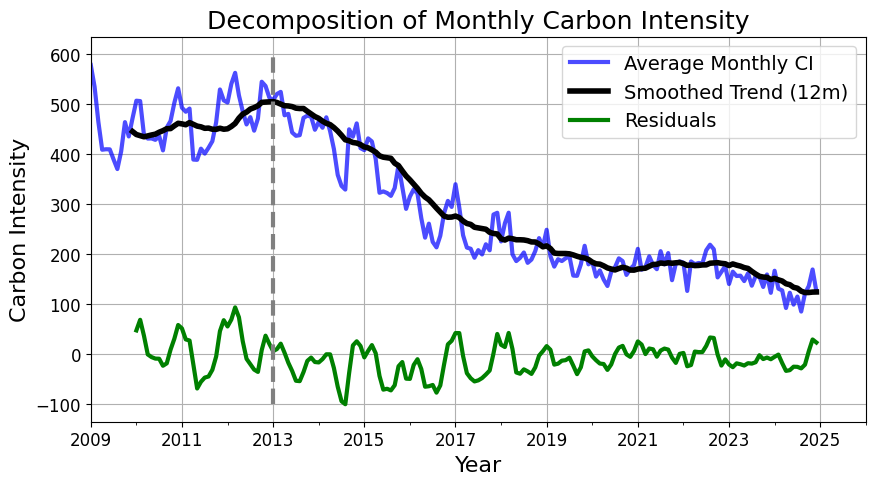

In [3]:
# Image 1
# Visually, the yearly trend of the training data does not linearly decrease, nor does a linear trend make sense;
# this would forecast a negative carbon intensity in the future, which is not possible. Thus, to diagnose a model
# to the trend, I crudely removed seasonal fluctuations from the data (averaging each month across the years and
# subtracting from actual CI; exploratory analysis, not an attempt to model the seasonality), and then applied a 
# rolling mean to smoothen the deseasoned data. The graph gives motivation for a piecewise regression model, with 
# a linear trend in the first period and log-linear trend in the second, and a breakpoint around 2013.

# Code
season = dft_m['CARBON_INTENSITY']
deseason = season - dft_m['CARBON_INTENSITY'].groupby(dft_m.index.month).transform('mean') 

season_smooth = season.rolling(window=12, center=False, min_periods=12).mean()
deseason_smooth = deseason.rolling(window=36, center=True, min_periods=18).mean()

residual_season = ((season - season_smooth))
residual_deseason = deseason - deseason_smooth

plt.figure(figsize=(10,5))
season.plot(alpha=0.7, label='Average Monthly CI', linewidth=3, color="blue", fontsize=12)
#deseason.plot(alpha=0.4, label='deseasoned')
season_smooth.plot(label='Smoothed Trend (12m)',linewidth=4, color='black', fontsize=12)
#deseason_smooth.plot(label='smooth deseasoned (36m)')

residual_season.rolling(window=2, center=False).mean().plot(label='Residuals', linewidth=3, color='green')

plt.xlabel("Year", fontsize=16)
plt.ylabel("Carbon Intensity", fontsize=16)
plt.vlines(pd.Timestamp("2013-01-01"), ymin=-100, ymax=600, colors='gray', linestyles='dashed', linewidth=3)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Decomposition of Monthly Carbon Intensity", fontsize=18)
plt.grid(True)
plt.savefig("Monthly Decomposition.png", dpi=300, bbox_inches="tight")
plt.show()


0.2628606999933254


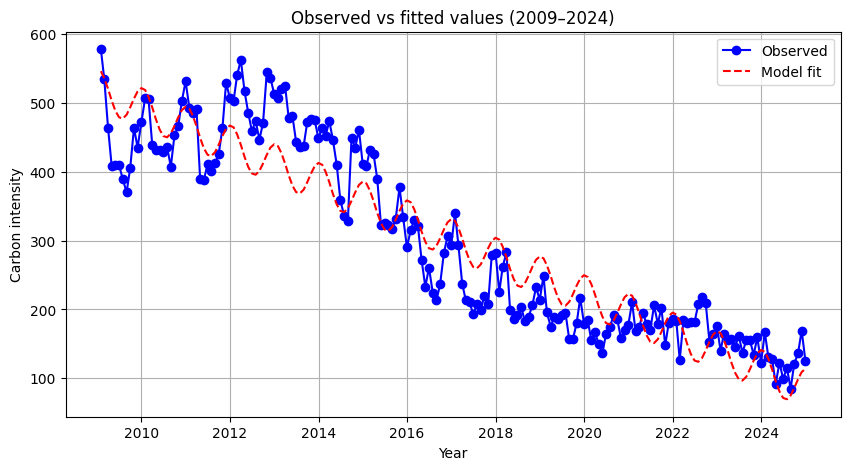

Rolling-origin score: 47.10 gCO2/kWh
MAE of fitted values: 44.00 gCO2/kWh


In [3]:
# Image 2
# Linear regression model
df = pd.read_csv('df_fuel_ckan.csv', parse_dates=['DATETIME'], usecols=['DATETIME', 'CARBON_INTENSITY'], index_col='DATETIME')

def linear_model(df, v_year=2025):
    dft = df[df.index.year < v_year]
    dfv = df[df.index.year == v_year]
    dfv_m = dfv.resample('ME').mean()

    dft_m = dft.resample('ME').mean()
    dft_m['t'] = np.arange(len(dft_m))
    dft_m['sin'] = np.sin(2 * np.pi * dft_m['t'] / 12)
    dft_m['cos'] = np.cos(2 * np.pi * dft_m['t'] / 12)

    X = sm.add_constant(dft_m[['t', 'sin', 'cos']])
    y = dft_m['CARBON_INTENSITY']
    model = sm.OLS(y, X).fit()
    dft_m['fitted'] = model.predict(X)

    start = dft_m['t'].iloc[-1] + 1
    dfv_m['t'] = np.arange(start, start + len(dfv_m))
    dfv_m['sin'] = np.sin(2 * np.pi * dfv_m['t'] / 12)
    dfv_m['cos'] = np.cos(2 * np.pi * dfv_m['t'] / 12)
    X_p = sm.add_constant(dfv_m[['t', 'sin', 'cos']])
    dfv_m['fitted'] = model.predict(X_p)

    return dft_m, dfv_m

start = time.perf_counter()
score = 0
for v_year in [2016, 2017, 2018, 2019,2020, 2021, 2022, 2023, 2024]:
    _, dfv_m = linear_model(df, v_year=v_year)
    score += mean_absolute_error(dfv_m['CARBON_INTENSITY'], dfv_m['fitted'])*np.exp(-(2024 - v_year)/4)/4.044

l_dft_m, _ = linear_model(df)
last = time.perf_counter()
print(last-start)
plt.figure(figsize=(10, 5))
plt.plot(l_dft_m.index, l_dft_m["CARBON_INTENSITY"], label="Observed", marker="o", color='blue')
plt.plot(l_dft_m.index, l_dft_m["fitted"], label="Model fit", linestyle="--", color='red')
plt.xlabel("Year")
plt.ylabel("Carbon intensity")
plt.title("Observed vs fitted values (2009–2024)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Rolling-origin score: {score:.2f} gCO2/kWh")
print(f"MAE of fitted values: {mean_absolute_error(l_dft_m['CARBON_INTENSITY'], l_dft_m['fitted']):.2f} gCO2/kWh")

Rolling-origin score: 31.4592 gCO2/kWh
Optimal breakpoint at t=60
MAE of fitted values: 31.36 gCO2/kWh
Execution time: 3.3842 seconds
Output accuracy: 24.811985941320042


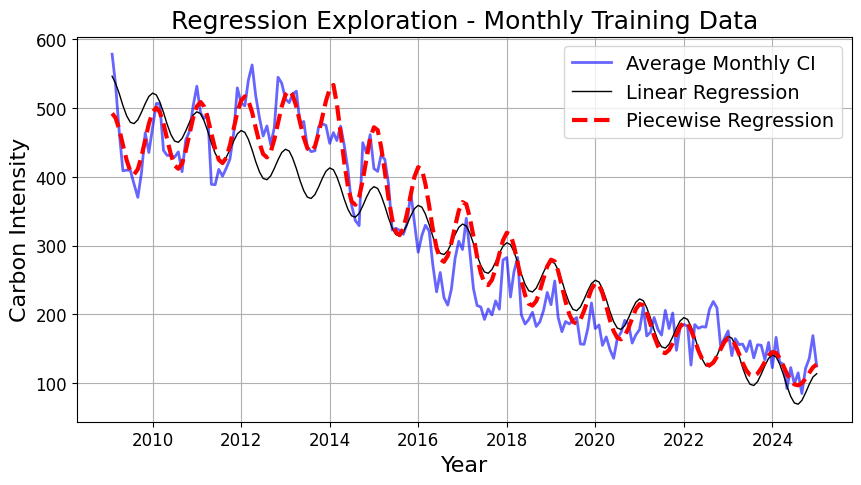

RV-MAE = 24.1928 and Training MAE = 23.7512
alpha=10, breakpoint=60, tau_s=36, iterations=44
[Regression, Monthly] MAE: 11.7584
[Regression, Monthly] RMSE: 14.0402
[Monthly] Benchmark MAE (using 2024 values for 2025): 16.2212
[Monthly] Benchmark RMSE (using 2024 values for 2025): 20.3150
Execution time: 1.6350 seconds


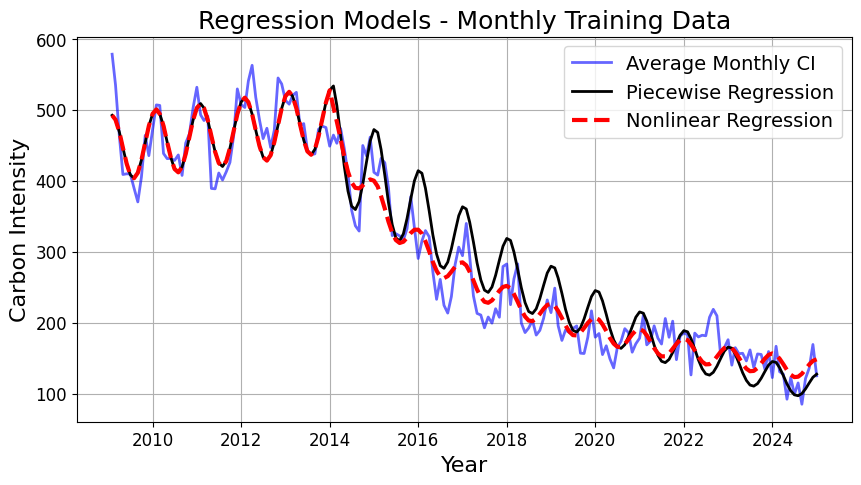

In [12]:
# Image 3
# Log-linear regression model 

df = pd.read_csv('df_fuel_ckan.csv', parse_dates=['DATETIME'], usecols=['DATETIME', 'CARBON_INTENSITY'], index_col='DATETIME')

def score(df, breakpoint):
    score = 0
    for v_year in [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]:
        _, dfv_m = OLD_regression_monthly(df, breakpoint, v_year=v_year)
        score += mean_absolute_error(dfv_m['CARBON_INTENSITY'], dfv_m['fitted']) * np.exp(-(2024 - v_year)/4)/4.044
    return score

def OLD_regression_monthly(df, breakpoint, v_year=2025):
    # 2.1 Prepare data for regression
    dft = df[df.index.year < v_year]
    dfv = df[df.index.year == v_year]
    dft_m = dft.resample('ME').mean()
    dft_m['t'] = np.arange(len(dft_m))
    dft_m['sin'] = np.sin(2 * np.pi * dft_m['t'] / 12)
    dft_m['cos'] = np.cos(2 * np.pi * dft_m['t'] / 12)

    # 2.2 Split pre- and post-breakpoint data
    pre = dft_m[dft_m['t'] <= breakpoint].copy()
    y_pre = pre['CARBON_INTENSITY']
    X_pre = pre[['t', 'sin', 'cos']]
    X_pre = sm.add_constant(X_pre)

    post = dft_m[dft_m['t'] >= breakpoint].copy()
    post['t'] = np.arange(len(post))
    post['sin'] = np.sin(2* np.pi * post['t'] / 12)
    post['cos-1'] = np.cos(2* np.pi * post['t'] / 12) - 1
    X_post = post[['t', 'sin', 'cos-1']]
    y_post = post['CARBON_INTENSITY']

    # 2.3 Model pre- and post- breakpoint data
    model_pre = sm.OLS(y_pre, X_pre).fit()
    pre['fitted'] = model_pre.fittedvalues
    y0 = pre['fitted'].iloc[-1]

    model_post = sm.OLS(np.log(y_post/y0), X_post).fit()
    post['fitted'] = y0 * np.exp(model_post.fittedvalues)

    post = post.drop(post.index[0])  

    dft_m['fitted'] = pd.concat([pre['fitted'], post['fitted']])
    dft_m['residual'] = dft_m['CARBON_INTENSITY'] - dft_m['fitted']

    # 2.4 Apply to future terms
    dfv_m = dfv.resample('ME').mean().copy()
    start = post['t'].iloc[-1] + 1
    dfv_m['t'] = np.arange(start, start + 12)
    dfv_m['sin'] = np.sin(2 * np.pi * dfv_m['t'] / 12)
    dfv_m['cos-1'] = np.cos(2 * np.pi * dfv_m['t'] / 12) - 1

    X_pred = dfv_m[['t', 'sin', 'cos-1']]

    predictions = y0 * np.exp(model_post.predict(X_pred))
    dfv_m['fitted'] = predictions

    return dft_m, dfv_m

start_time = time.perf_counter()
final = 900000
best_score = 0
best_break = 0
for n in np.arange(48, 61):

    points = score(df, n)
    if points > best_score:
        best_score = points
        best_break = n

dft_m, dfv_m = OLD_regression_monthly(df, best_break)
print(f"Rolling-origin score: {best_score:.4f} gCO2/kWh")
print(f"Optimal breakpoint at t={best_break}")
print(f"MAE of fitted values: {mean_absolute_error(dft_m['CARBON_INTENSITY'], dft_m['fitted']):.2f} gCO2/kWh")

end_time = time.perf_counter()

print(f"Execution time: {end_time - start_time:.4f} seconds")
print(f"Output accuracy: {mean_absolute_error(dfv_m['CARBON_INTENSITY'],dfv_m['fitted'])}")

plt.figure(figsize=(10, 5))
plt.plot(dft_m.index, dft_m["CARBON_INTENSITY"], label="Average Monthly CI", color='blue', linewidth=2, alpha=0.6)
plt.plot(l_dft_m.index, l_dft_m["fitted"], label="Linear Regression", linestyle="-", color='black', linewidth=1)
plt.plot(dft_m.index, dft_m["fitted"], label="Piecewise Regression", linestyle="--", color='red', linewidth=3)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Carbon Intensity", fontsize=16)
plt.title("Regression Exploration - Monthly Training Data", fontsize=18)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.savefig("Monthly Regression Exploration.png", dpi=300, bbox_inches="tight")
plt.show()

dftn_m, _, _, _, _, _, _ = run_regression_monthly(df)

plt.figure(figsize=(10, 5))
plt.plot(dftn_m.index, dftn_m["CARBON_INTENSITY"], label="Average Monthly CI", color='blue', linewidth=2, alpha=0.6)
plt.plot(dft_m.index, dft_m["fitted"], label="Piecewise Regression", linestyle="-", color='black', linewidth=2)
plt.plot(dftn_m.index, dftn_m["fitted"], label="Nonlinear Regression", linestyle="--", color='red', linewidth=3)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Carbon Intensity", fontsize=16)
plt.title("Regression Models - Monthly Training Data", fontsize=18)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.savefig("Nonlinear Regression Fit.png", dpi=300, bbox_inches="tight")
plt.show()

RV-MAE = 24.1928 and Training MAE = 23.7512
alpha=10, breakpoint=60, tau_s=36, iterations=44
[Regression, Monthly] MAE: 11.7584
[Regression, Monthly] RMSE: 14.0402
[Monthly] Benchmark MAE (using 2024 values for 2025): 16.2212
[Monthly] Benchmark RMSE (using 2024 values for 2025): 20.3150
Execution time: 1.4805 seconds
[Recomposition, Monthly] MAE: 22.640939389460428
[Recomposition, Monthly] RMSE: 25.577522396176338
Execution time: 0.0548 seconds


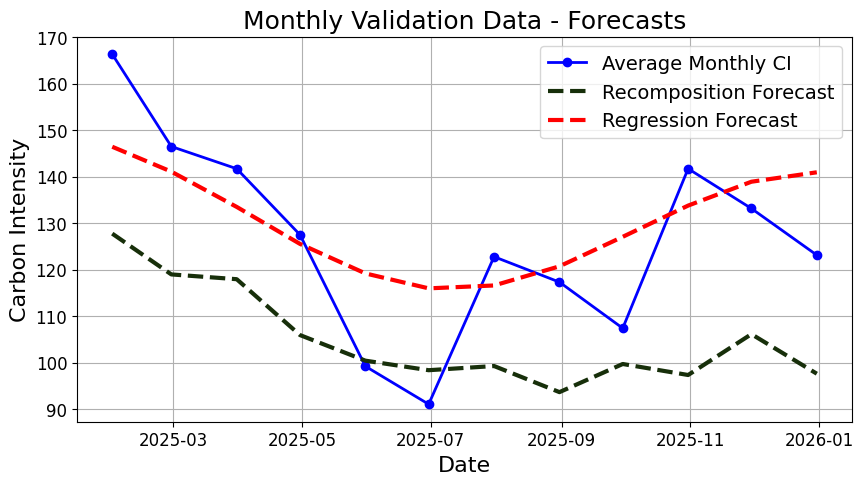

Text(0.5, 1.0, 'Regression Model - Monthly Training Data')

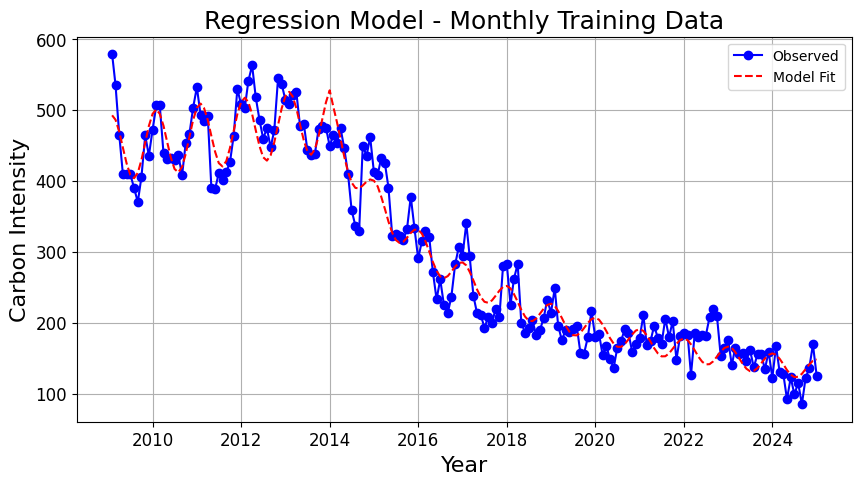

In [10]:
# Images 4 & 5
# Monthly regression of both models
df = pd.read_csv('df_fuel_ckan.csv', parse_dates=['DATETIME'], usecols=['DATETIME', 'CARBON_INTENSITY'], index_col='DATETIME')
dft_m, dfv_m, a_hat, tau_hat, p_hat, breakpoint, tau_s = run_regression_monthly(df)
monthly_forecast = recomposition_monthly(df)

plt.figure(figsize=(10,5))
plt.plot(dfv_m.index, dfv_m['CARBON_INTENSITY'], color='blue', label='Average Monthly CI', marker='o', linewidth=2)
plt.plot(monthly_forecast.index, monthly_forecast.values, color='#172F0A', label='Recomposition Forecast', linestyle='--', linewidth=3)
plt.plot(dfv_m.index, dfv_m['fitted'], color='red', label='Regression Forecast', linestyle='--', linewidth=3)
plt.legend(fontsize=14)
plt.title('Monthly Validation Data - Forecasts', fontsize=18)
plt.ylabel('Carbon Intensity', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.grid('True')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig("Monthly Forecasts.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(dft_m.index, dft_m['CARBON_INTENSITY'], label="Observed", marker="o", color='blue')
plt.plot(dft_m.index, dft_m['fitted'], label="Model Fit", linestyle="--", color='red')
plt.legend()
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Carbon Intensity', fontsize=16)
plt.title('Regression Model - Monthly Training Data', fontsize=18)


C:\Users\zainh\AppData\Local\Temp\ipykernel_29756\420423360.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_h = df.resample('H').mean()
C:\Users\zainh\AppData\Local\Temp\ipykernel_29756\420423360.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dft_h['t'] = np.arange(len(dft_h))
C:\Users\zainh\AppData\Local\Temp\ipykernel_29756\420423360.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dft_h["rel_ci"] = dft_h["CARBON_INTENSITY"] / monthly_m

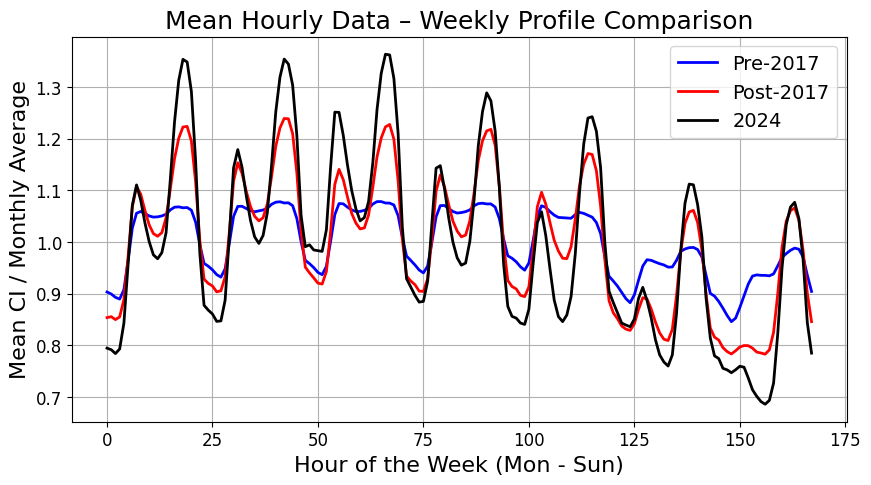

In [11]:
# Image 6
# Justification for structure of hourly regression

v_year = 2025
df_h = df.resample('H').mean()
dft_h = df_h[df_h.index.year < v_year]
dfv_h = df_h[df_h.index.year == v_year]
dft_h['t'] = np.arange(len(dft_h))

# training data
monthly_mean = (dft_h.groupby(dft_h.index.to_period('M'))['CARBON_INTENSITY'].transform('mean'))
dft_h["rel_ci"] = dft_h["CARBON_INTENSITY"] / monthly_mean
dft_h["log_rel_ci"] = np.log(dft_h["rel_ci"])

dftl = dft_h[dft_h.index.year < 2017]
dftk = dft_h[dft_h.index.year >= 2017]
dftm = dft_h[dft_h.index.year == 2024]

dftl['dow'] = dftl.index.dayofweek
dftl['hour'] = dftl.index.hour
weekly_profilel = (dftl.groupby(['dow', 'hour'])['rel_ci'].mean())
weekly_seriesl = weekly_profilel.reset_index()
weekly_seriesl['week_hour'] = weekly_seriesl['dow'] * 24  + weekly_seriesl['hour']
weekly_seriesl = weekly_seriesl.sort_values('week_hour')

dftk['dow'] = dftk.index.dayofweek
dftk['hour'] = dftk.index.hour
weekly_profilek = (dftk.groupby(['dow', 'hour'])['rel_ci'].mean())
weekly_seriesk = weekly_profilek.reset_index()
weekly_seriesk['week_hour'] = (weekly_seriesk['dow']+0) * 24  + weekly_seriesk['hour'] 
weekly_seriesk = weekly_seriesk.sort_values('week_hour')

dftm['dow'] = dftm.index.dayofweek
dftm['hour'] = dftm.index.hour
weekly_profilem = (dftm.groupby(['dow', 'hour'])['rel_ci'].mean())
weekly_seriesm = weekly_profilem.reset_index()
weekly_seriesm['week_hour'] = (weekly_seriesm['dow']+0) * 24  + weekly_seriesm['hour'] 
weekly_seriesm = weekly_seriesm.sort_values('week_hour')


plt.figure(figsize=(10, 5))
plt.plot(weekly_seriesl['week_hour'], weekly_seriesl['rel_ci'], color='blue', linewidth=2)
plt.plot(weekly_seriesk['week_hour'], weekly_seriesk['rel_ci'], color='red', linewidth=2)
plt.plot(weekly_seriesm['week_hour'], weekly_seriesm['rel_ci'], color='black', linewidth=2)
plt.legend(['Pre-2017', 'Post-2017', '2024'], fontsize=14)
plt.title("Mean Hourly Data – Weekly Profile Comparison", fontsize=18)
plt.xlabel("Hour of the Week (Mon - Sun)", fontsize=16)
plt.ylabel("Mean CI / Monthly Average", fontsize=16)
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig("Hourly Weekly Profile.png", dpi=300, bbox_inches="tight")
plt.show()

alpha=300
[Regression, Hourly] MAE: 45.75732674443919
[Regression, Hourly] RMSE: 54.66100220511399
Benchmark MAE (using 2024 values for 2025): 56.33276255707762
Benchmark RMSE (using 2024 values for 2025): 70.7181443200616
Execution time (hourly): 2.2326 seconds
[Recomposition, Monthly] MAE: 22.640939389460428
[Recomposition, Monthly] RMSE: 25.577522396176338
Execution time: 0.0292 seconds
[Recomposition, Hourly] MAE (using monthly forecast): 45.64212922091119
[Recomposition, Hourly] RMSE (using monthly forecast): 57.22442939998566
[Recomposition, Hourly] MAE (using monthly values): 42.18761646600417
[Recomposition, Hourly] RMSE (using monthly values): 51.312446467617846
Execution time: 0.0721 seconds


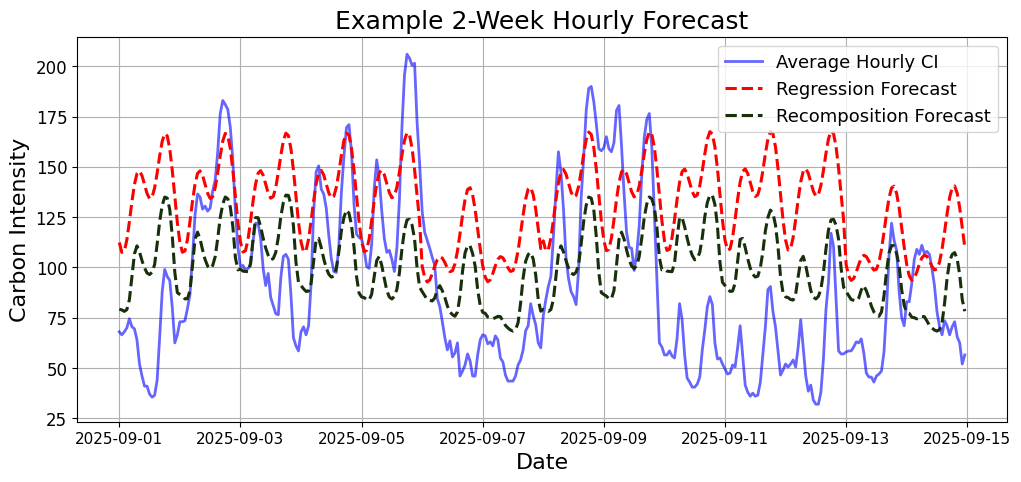

In [16]:
# Image 7
# Hourly regression of both models

_, dfv_h = run_regression_hourly(df, a_hat, tau_hat, p_hat, breakpoint, tau_s)
monthly_forecast = recomposition_monthly(df)
hourly_forecast = recomposition_hourly(df, monthly_forecast)

date_reg = dfv_h.loc['2025-09-01 00:00:00':'2025-09-14 23:00:00'].copy()
date_rec = hourly_forecast.loc['2025-09-01 00:00:00':'2025-09-14 23:00:00'].copy()

plt.figure(figsize=(12, 5))
plt.plot(date_reg.index, date_reg['CARBON_INTENSITY'], label="Average Hourly CI", color='blue', linewidth=2, alpha=0.6)
plt.plot(date_reg.index, date_reg['fitted'], label="Regression Forecast", linestyle="--", color='red', linewidth=2.2)
plt.plot(date_rec.index, date_rec.values, label="Recomposition Forecast", linestyle="--", color="#172F0A", linewidth=2.2)
plt.legend(fontsize=13)
plt.grid(True)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Carbon Intensity', fontsize=16)
plt.title('Example 2-Week Hourly Forecast', fontsize=18)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)
plt.savefig("Example Hourly Forecast.png", dpi=300, bbox_inches="tight")
plt.show()
